### **DATA PREPROCESSING**

In [1]:
import pandas as pd
from scipy import stats
from sklearn.datasets import load_iris
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

In [2]:
# lets import our dataset from scikt-learn
from sklearn.datasets import load_iris

In [6]:
# lets import pandas to load the dataset as a dataframe
import pandas as pd

iris_flower = load_iris()

# lets load the feature dataset
features = pd.DataFrame(iris_flower.data, columns=iris_flower.feature_names)

# lets load the target dataset
target = iris_flower.target

In [7]:
# lets view
features.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
print(target)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


#### 1. Handling Missing Values

In [12]:
features.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

In [13]:
# lets take a snapshort of our dataset
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


This dataset does not have missing values, but we will introduce missing values. I think you should be excited.LOL.

Remember indexing and slicing  using `.iloc[]` and `.loc[]` in pandas class?

In [17]:
features.shape

(150, 4)

In [15]:
# lets introduce missing values
features.loc[10, "sepal length (cm)"] = None
features.loc[50:54, "sepal width (cm)"] = None
features.loc[100:102, "petal length (cm)"] = None

In [16]:
# lets check for missing values again..
features.isnull().sum()

sepal length (cm)    1
sepal width (cm)     5
petal length (cm)    3
petal width (cm)     0
dtype: int64

In [18]:
# Now lets handle the missing values

# lets iomport the imputer library
from sklearn.impute import SimpleImputer

In [19]:
# lets create an instance of the imputer class using 'mean as strategy for imputation
impute_mean = SimpleImputer(strategy='mean')

# Lets create an instance of the imputer class using 'median' as strategy for imputation
impute_median = SimpleImputer(strategy='median')

In [20]:
# lets apply the defined instances above
features[["sepal length (cm)"]] = impute_mean.fit_transform(features[['sepal length (cm)']])
features[['sepal width (cm)']] = impute_mean.fit_transform(features[['sepal width (cm)']])
features[['petal length (cm)']] = impute_median.fit_transform(features[['petal length (cm)']])

In [21]:
features.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

#### 2. Handling Outliers

In [25]:
# Lets practice

from scipy import stats
z_scores = stats.zscore(features)



In [26]:
print(z_scores)

[[-9.05163302e-01  1.02053680e+00 -1.34014407e+00 -1.31544430e+00]
 [-1.14773404e+00 -1.44643012e-01 -1.34014407e+00 -1.31544430e+00]
 [-1.39030478e+00  3.21428915e-01 -1.39764453e+00 -1.31544430e+00]
 [-1.51159016e+00  8.83929516e-02 -1.28264361e+00 -1.31544430e+00]
 [-1.02644867e+00  1.25357277e+00 -1.34014407e+00 -1.31544430e+00]
 [-5.41307191e-01  1.95268066e+00 -1.16764268e+00 -1.05217993e+00]
 [-1.51159016e+00  7.87500841e-01 -1.34014407e+00 -1.18381211e+00]
 [-1.02644867e+00  7.87500841e-01 -1.28264361e+00 -1.31544430e+00]
 [-1.75416090e+00 -3.77678975e-01 -1.34014407e+00 -1.31544430e+00]
 [-1.14773404e+00  8.83929516e-02 -1.28264361e+00 -1.44707648e+00]
 [ 0.00000000e+00  1.48660873e+00 -1.28264361e+00 -1.31544430e+00]
 [-1.26901941e+00  7.87500841e-01 -1.22514315e+00 -1.31544430e+00]
 [-1.26901941e+00 -1.44643012e-01 -1.34014407e+00 -1.44707648e+00]
 [-1.87544627e+00 -1.44643012e-01 -1.51264545e+00 -1.44707648e+00]
 [-5.61657085e-02  2.18571662e+00 -1.45514499e+00 -1.31544430e

**Removal Method**

In [28]:
# Lets filter out the outliers --> features[condition]

#abs()--> help to handle -ve value if there is any..

# feature_with_no_outliers = df[abs(stats.zscore(features["sepal length (cm)"])) < 3]--> This will filter for only one column

# lets create a copy of our datasets

handle_outliers_1 = features.copy()
features_with_removed_outliers = handle_outliers_1[abs(z_scores < 3).all(axis=1)]  # .all(axis=1) is signifying that i am selecting all the columns


In [29]:
features_with_removed_outliers.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [30]:
features.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


**Capping Method**

In [41]:
import numpy as np

# lets create a copy of our dataframe
handle_outliers_2 = features.copy()

# lets define the threshold first
threshold = 3

# lets apply capping to our calculated z-scores
### Lets apply a little bit of complexity to it incase you are going to be selecting the numeric columns in your own dataset, it works here but doesnt really applies to this case though.
### creating a loop to handle both the limits and the capping of the selected columns

for i, col in enumerate(handle_outliers_2.select_dtypes(include=[np.number]).columns):
  # lets select the outliers
  outliers = handle_outliers_2[col][abs(stats.zscore(handle_outliers_2[col])) > threshold]
  # lets cap anything outside the threshold
  # Use.iloc[] to access the z_scores values
  handle_outliers_2[col] = np.where(np.abs(z_scores.iloc[:, i]) > threshold, handle_outliers_2[col].clip(lower=outliers.min(), upper=outliers.max()), handle_outliers_2[col]) #Using clip to cap outliers within the IQR range

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

In [39]:
handle_outliers_2.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


##### **3. Feature Scaling(Normalization / Standardization)**

In [42]:
# lets import the scaling libraries, take note of how I imported  the library
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [46]:
# Lets standerdize the dataset

# Lets create a copy of our dataset
standardize_features = features.copy()

#create an instance of the StandardScaler class
scaler = StandardScaler()

# lets say you want to apply it to a particular column
# standardized_sepal_length = scaler.fit_transform(standardized_features[["sepal length (cm)"]])

# But i am applying it yo the whole dataset
standard_features = scaler.fit_transform(standardize_features)

In [48]:
# print(standard_features)

In [50]:
# We have already imported the MinMaxScaler() class(for normalizing)

# Lets normalize the dataset

# lets create a copy of our dataset
normalize_features = features.copy()

#create an instance of the MinMaxScaler() class
normalizer = MinMaxScaler()

# lets say youwant to apply it to a particular column
#standardized_sepal_length = normalizer.fit_transform(standardized_features[["sepal length (cm)"]])

# But I am applying it to the whole dataset
normal_features = normalizer.fit_transform(normalize_features)

In [52]:
# print(normal_features)

##### **4. Data Splitting**

In [54]:
#import the train_test_split() function --> The name is quite intuitive
from sklearn.model_selection import train_test_split

# Lets make a copy of our dataset
feature_data = features.copy()
target_data = target.copy()

# Lets split the data --> Take time to understand the arrangement of the variable names and their font cases
X_train, X_test, y_train, y_test =train_test_split(feature_data, target_data, test_size=0.3, random_state=234)

# Lets print the shape of the features
print(f'Training set size: {X_train.shape}')
print(f'Test set size: {X_test.shape}')

print("")
# Lets print for the target- which should be in a single column
print(f'Training set size: {y_train.shape}')
print(f'Test set size: {y_test.shape}')

Training set size: (105, 4)
Test set size: (45, 4)

Training set size: (105,)
Test set size: (45,)


#### **5. Feature Selection**

**1. Embeded Method**

**2. Wrapper Method**

**3. Filter Method**

In [55]:
# Lets import the class for feature selection
from sklearn.feature_selection import SelectKBest, f_classif

In [58]:
features.shape

(150, 4)

In [57]:
# Lets make a copy of the dataset
selection_features = features.copy()
selection_target = target.copy()

# LEts create an instancce of SelectKBest()
best_features = SelectKBest(score_func=f_classif, k=3) # I am pick 3 for K since we only have 4 features
selected_best_features = best_features.fit_transform(selection_features, selection_target)

# lets check the shape of the selected features
selected_best_features. shape


(150, 3)

In [61]:
features.head(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2


In [60]:
selected_best_features

array([[5.1       , 1.4       , 0.2       ],
       [4.9       , 1.4       , 0.2       ],
       [4.7       , 1.3       , 0.2       ],
       [4.6       , 1.5       , 0.2       ],
       [5.        , 1.4       , 0.2       ],
       [5.4       , 1.7       , 0.4       ],
       [4.6       , 1.4       , 0.3       ],
       [5.        , 1.5       , 0.2       ],
       [4.4       , 1.4       , 0.2       ],
       [4.9       , 1.5       , 0.1       ],
       [5.84630872, 1.5       , 0.2       ],
       [4.8       , 1.6       , 0.2       ],
       [4.8       , 1.4       , 0.1       ],
       [4.3       , 1.1       , 0.1       ],
       [5.8       , 1.2       , 0.2       ],
       [5.7       , 1.5       , 0.4       ],
       [5.4       , 1.3       , 0.4       ],
       [5.1       , 1.4       , 0.3       ],
       [5.7       , 1.7       , 0.3       ],
       [5.1       , 1.5       , 0.3       ],
       [5.4       , 1.7       , 0.2       ],
       [5.1       , 1.5       , 0.4       ],
       [4.

##### **6. Dimensionality Reduction**

In [62]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [63]:
# Lets load dataset
digits = load_digits()

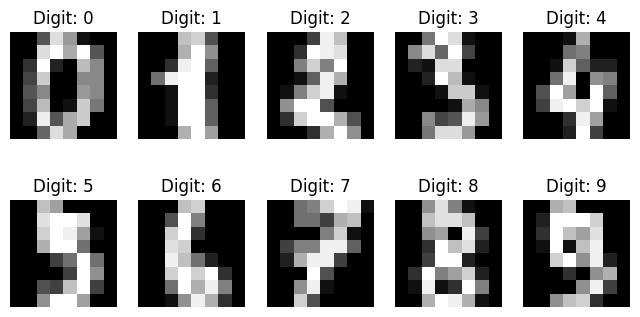

In [64]:
# Lets view our digit data(target)
fig, axes = plt.subplots(2, 5, figsize=(8, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Digit: {digits.target[i]}")
    ax.axis("off")
plt.show()